<a href="https://colab.research.google.com/github/Aiswarya-2sathyakumar/ICT_DSA-2026/blob/main/Unsupervised_learning_case_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Clustering
from sklearn.cluster import KMeans

#Data loading

In [ ]:
#load data
customer_df = pd.read_csv("/content/Mall_Customers (1).csv")

#Data analysis

In [ ]:
customer_df.head()

In [ ]:
customer_df.isna().sum()

###Data Preprocessing

In [ ]:
X = customer_df.drop('CustomerID', axis=1)

###Encode the "Genre" column

In [ ]:
X.head()

In [ ]:
X["Genre"].unique()

In [ ]:
#encoding "genre"--using value mapping
X['Genre']=X['Genre'].map({'Male':0,'Female':1})

X['Genre'].unique()

In [ ]:
#other way
X["Genre"] = X["Genre"].map({
    "Male": 1,
    "Female": 0
})

In [ ]:
#list to store WCS value for each value of K
wcss = []
#find wcss value for each
for i in range (1,11):
k_means_model = KMeans(n_clusters =i, n_init=5)
k_means_model.fit(x)
wcss_value =k_means_model.inertia_ #value of wcss for k=1

wcss.append(wcss_value)

In [ ]:
# List to store WCSS values
wcss = []

# Finding WCSS value for different K values
for i in range(1, 11):
    k_means_model = KMeans(n_clusters=i, n_init=5)

    k_means_model.fit(X)

    # WCSS value
    wcss_value = k_means_model.inertia_

    wcss.append(wcss_value)

print(wcss)

[308862.06000000006, 212889.44245524294, 143391.59236035674, 104414.67534220174, 75427.71182424152, 58348.64136331505, 51165.18423710792, 44392.11566567934, 41135.631927105125, 37961.38721278722]


In [ ]:
#checking WCSS values
wcss

[308862.06000000006,
 212889.44245524294,
 143391.59236035674,
 104414.67534220174,
 75427.71182424152,
 58348.64136331505,
 51165.18423710792,
 44392.11566567934,
 41135.631927105125,
 37961.38721278722]

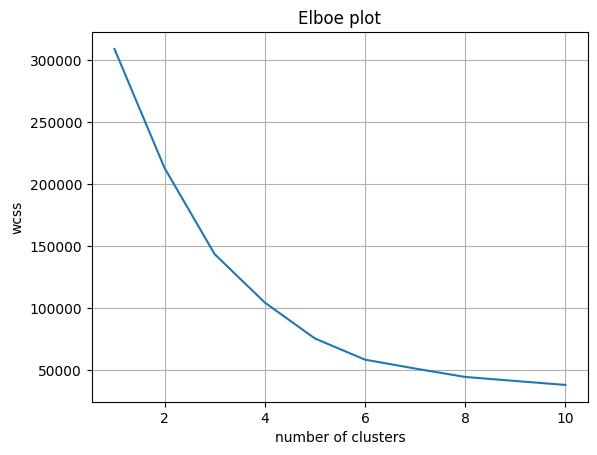

In [ ]:
plt.plot(range(1,11), wcss)
plt.title("Elboe plot")
plt.xlabel("number of clusters")
plt.ylabel("wcss" )
plt.grid()
plt.show()

In [ ]:
#optimum no of clusters = 6
#inference from the elbow plot

#now create a k means model with no of clusters = 6
#initialize model
k_means = KMeans(n_clusters =6, n_init=5)

#model building
k_means.fit(X)

#model prediction
cluster_label = k_means.predict(X)

cluster_label

array([4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5,
       4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 0, 5, 4, 1,
       4, 5, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 2, 1, 2, 1, 2, 3, 2, 3, 2,
       1, 2, 3, 2, 3, 2, 3, 2, 3, 2, 1, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2], dtype=int32)

In [ ]:
#check how many rows in each cluster
customer_df['cluster'].value_counts

<bound method IndexOpsMixin.value_counts of 0      4
1      5
2      4
3      5
4      4
      ..
195    2
196    3
197    2
198    3
199    2
Name: cluster, Length: 200, dtype: int32>

##Visualizing clusters

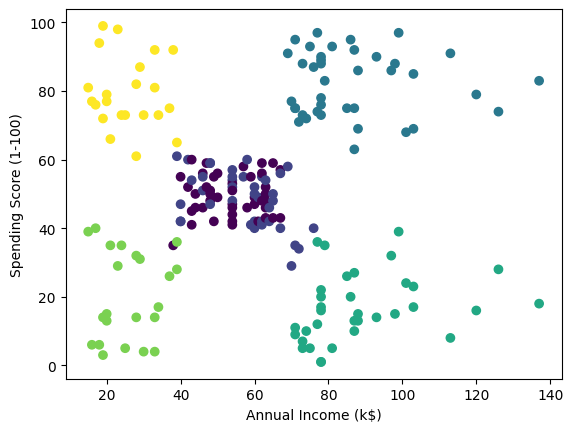

In [ ]:
##plot showing Annual income (k$) vs Spending score(1-100)

plt.scatter(customer_df['Annual Income (k$)'],
            customer_df['Spending Score (1-100)'],
            c= customer_df["cluster"])

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")

plt.show()

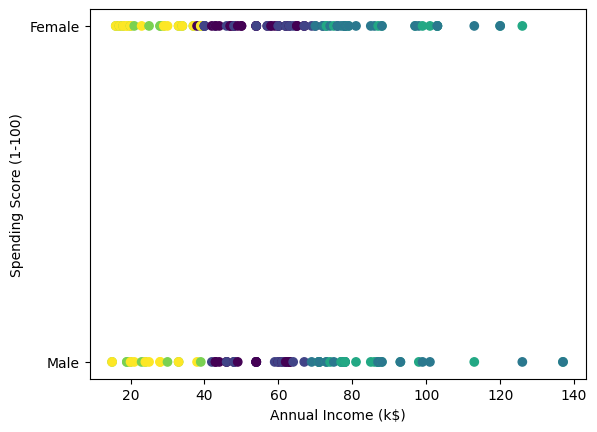

In [ ]:
##plot showing Annual income (k$) vs Age

plt.scatter(customer_df['Annual Income (k$)'],
            customer_df['Genre'],
            c= customer_df["cluster"])

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")

plt.show()